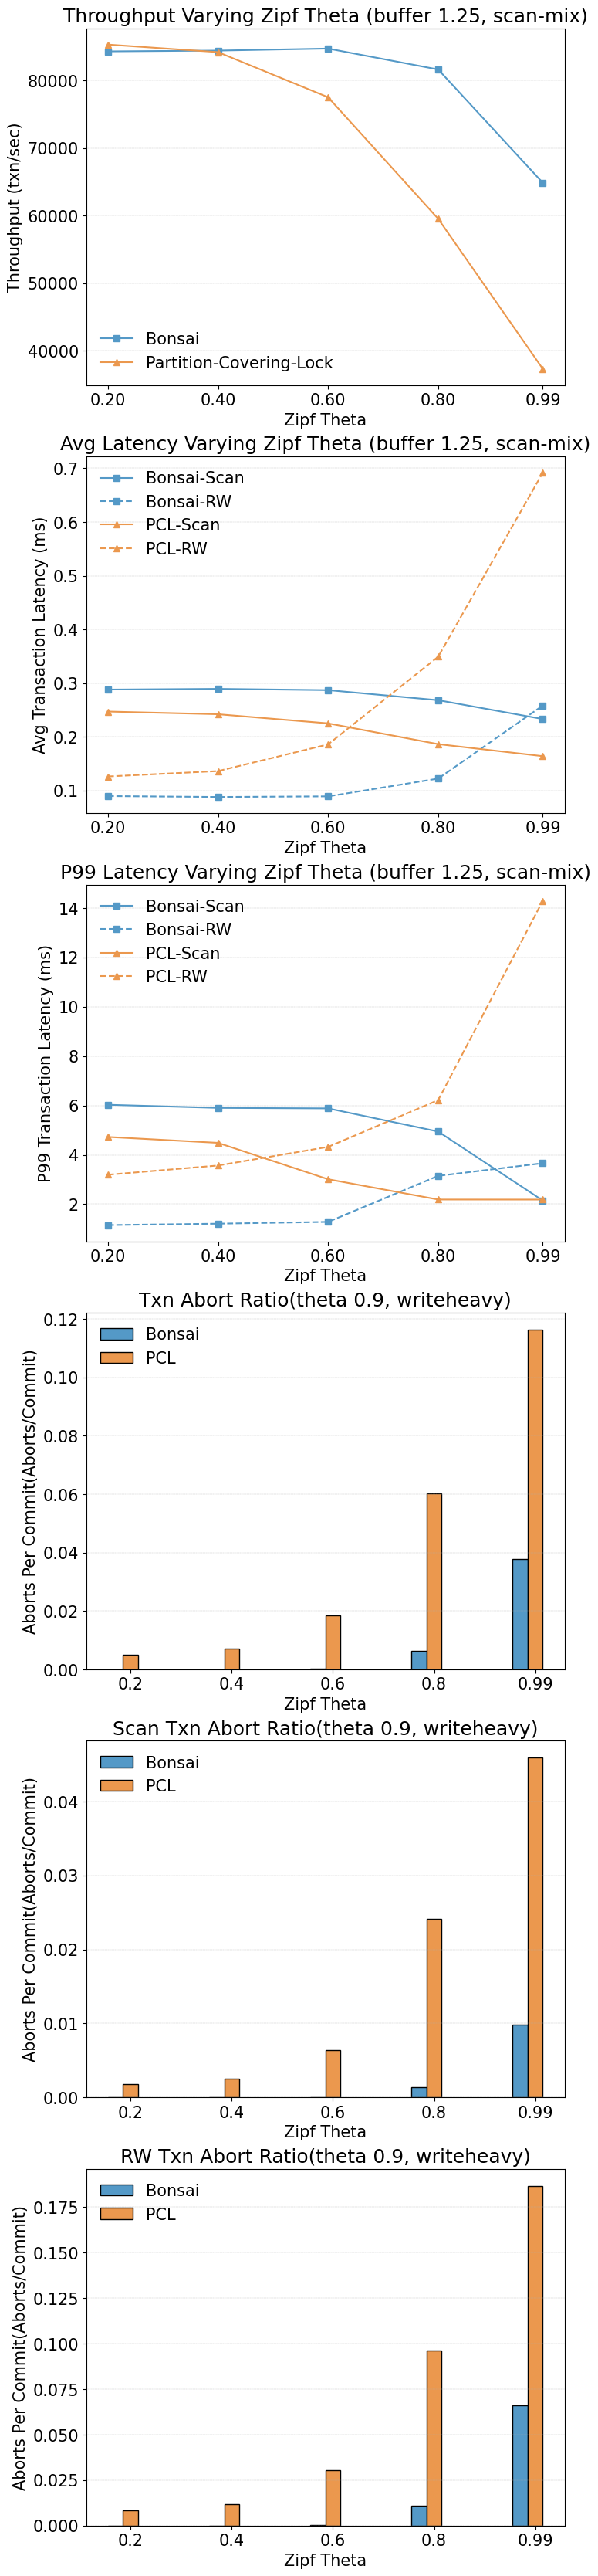

In [12]:
from process_helper import *
import numpy as np

# _, grad_colors = display_colors()
# _, bar_colors = select_color_idx(4)
color_indices, line_colors = select_color_idx(4)

plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5
idxs = ["g_total_buf_sz", "read_perc_","g_total_buf_sz"]
datadir = "../output/"
exp_next_key = "exp_scan_mix_vary_zipf"
exp_partition_lock = "exp_mix_scan_partition_lock_vary_zipf"

data_next_key = [json.loads(line) for line in open(datadir + exp_next_key + ".txt")]
df_next_key = pd.DataFrame().from_records(data_next_key)
df_next_key = df_next_key.sort_values(by='zipf_theta_')

data_partition_lock = [json.loads(line) for line in open(datadir + exp_partition_lock + ".txt")]
df_partition_lock = pd.DataFrame().from_records(data_partition_lock)
df_partition_lock = df_partition_lock.sort_values(by='zipf_theta_')

# print(df_tuple)
fig = plt.figure(figsize=(8, 42))

# fig, ax = plt.subplots()
ax = fig.add_subplot(6, 1, 1)


ax.plot(df_next_key["zipf_theta_"], 
        df_next_key["throughput_txn_per_sec"],
        color=line_colors["BLUE"],
        marker="s", label="Bonsai")


ax.plot(df_partition_lock["zipf_theta_"], 
        df_partition_lock["throughput_txn_per_sec"],
        color=line_colors["ORANGE"],
        marker="^", label="Partition-Covering-Lock")

# ax.set_ylim(10, 11000)
#ax.set_xlim(0, 1)
ax.set_xticks(df_next_key["zipf_theta_"])
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Throughput (txn/sec)")
ax.set_xlabel("Zipf Theta")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Throughput Varying Zipf Theta (buffer 1.25, scan-mix)")



ax = fig.add_subplot(6, 1, 2)


ax.plot(df_next_key["zipf_theta_"], 
        df_next_key["avg_sum_scan_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai-Scan")
ax.plot(df_next_key["zipf_theta_"], 
        # df_tuple["txn_latency_perc99_us"]/1000,
        df_next_key["avg_sum_rw_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai-RW", linestyle='dashed')


ax.plot(df_partition_lock["zipf_theta_"], 
    # df_tuple["txn_latency_perc99_us"]/1000,
        df_partition_lock["avg_sum_scan_txn_latency (us)"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-Scan")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page["g_total_buf_sz"])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_partition_lock["zipf_theta_"], 
    # df_page_idx_evict["txn_latency_perc99_us"]/1000,
        df_partition_lock["avg_sum_rw_txn_latency (us)"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-RW", linestyle='dashed')

# ax.set_ylim(0, 125)
#ax.set_xlim(0, 1)
ax.set_xticks(df_next_key["zipf_theta_"])
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Avg Transaction Latency (ms)")
# ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
ax.set_xlabel("Zipf Theta")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Avg Latency Varying Zipf Theta (buffer 1.25, scan-mix)")


ax = fig.add_subplot(6, 1, 3)


# ax.plot(df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000), 
#         # df_tuple["txn_latency_perc99_us"]/1000,
#         df_tuple["avg_sum_txn_latency (us)"]/1000,
#         color=line_colors["BLUE"],
#         marker="s", label="Bonsai")

ax.plot(df_next_key["zipf_theta_"], 
        df_next_key["scan_txn_latency_perc99_us"]/1000,
        # df_tuple["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai-Scan")

ax.plot(df_next_key["zipf_theta_"], 
        df_next_key["rw_txn_latency_perc99_us"]/1000,
        # df_tuple["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai-RW",linestyle='dashed')



ax.plot(df_partition_lock["zipf_theta_"], 
        df_partition_lock["scan_txn_latency_perc99_us"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-Scan")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page["g_total_buf_sz"])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_partition_lock["zipf_theta_"], 
        df_partition_lock["rw_txn_latency_perc99_us"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-RW", linestyle='dashed')

# ax.set_ylim(0, 700)
#ax.set_xlim(0, 1)
ax.set_xticks(df_next_key["zipf_theta_"])
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "upper left"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("P99 Transaction Latency (ms)")
ax.set_xlabel("Zipf Theta")
# ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("P99 Latency Varying Zipf Theta (buffer 1.25, scan-mix)")


index = np.arange(len(df_next_key["zipf_theta_"]))

bar_width = 0.15

# _, ax1 = plt.subplots()
ax1 = fig.add_subplot(6, 1, 4)


ax1.bar(index + 1 * bar_width, 
        df_next_key["abort_cnt_"]/df_next_key["txn_cnt_"] , bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        df_partition_lock["abort_cnt_"]/df_partition_lock["txn_cnt_"], bar_width, edgecolor='black',
        color=line_colors["ORANGE"],
        label="PCL")

# plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["zipf_theta_"]*100/(12*1000*1000*1000))
plt.xticks(index + bar_width * (5 - 1) / 2, df_next_key["zipf_theta_"])

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Aborts Per Commit(Aborts/Commit)")
ax1.set_xlabel("Zipf Theta")
# ax1.set_xscale('log')
ax1.set_title("Txn Abort Ratio(theta 0.9, writeheavy)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)


# _, ax1 = plt.subplots()
ax1 = fig.add_subplot(6, 1, 5)


ax1.bar(index + 1 * bar_width, 
        df_next_key["scan_abort_cnt_"]/df_next_key["scan_txn_cnt_"] , bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        df_partition_lock["scan_abort_cnt_"]/df_partition_lock["scan_txn_cnt_"], bar_width, edgecolor='black',
        color=line_colors["ORANGE"],
        label="PCL")

# plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["zipf_theta_"]*100/(12*1000*1000*1000))
plt.xticks(index + bar_width * (5 - 1) / 2, df_next_key["zipf_theta_"])

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Aborts Per Commit(Aborts/Commit)")
ax1.set_xlabel("Zipf Theta")
# ax1.set_xscale('log')
ax1.set_title("Scan Txn Abort Ratio(theta 0.9, writeheavy)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)


ax1 = fig.add_subplot(6, 1, 6)


ax1.bar(index + 1 * bar_width, 
        df_next_key["rw_abort_cnt_"]/df_next_key["rw_txn_cnt_"] , bar_width,edgecolor='black',
        color=line_colors["BLUE"],
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        df_partition_lock["rw_abort_cnt_"]/df_partition_lock["rw_txn_cnt_"], bar_width, edgecolor='black',
        color=line_colors["ORANGE"],
        label="PCL")

# plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["zipf_theta_"]*100/(12*1000*1000*1000))
plt.xticks(index + bar_width * (5 - 1) / 2, df_next_key["zipf_theta_"])

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Aborts Per Commit(Aborts/Commit)")
ax1.set_xlabel("Zipf Theta")
# ax1.set_xscale('log')
ax1.set_title("RW Txn Abort Ratio(theta 0.9, writeheavy)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)



Text(0.5, 1.0, 'P99 Latency Varying Partition Size (buffer 1.25, theta 0.9, scan-mix)')

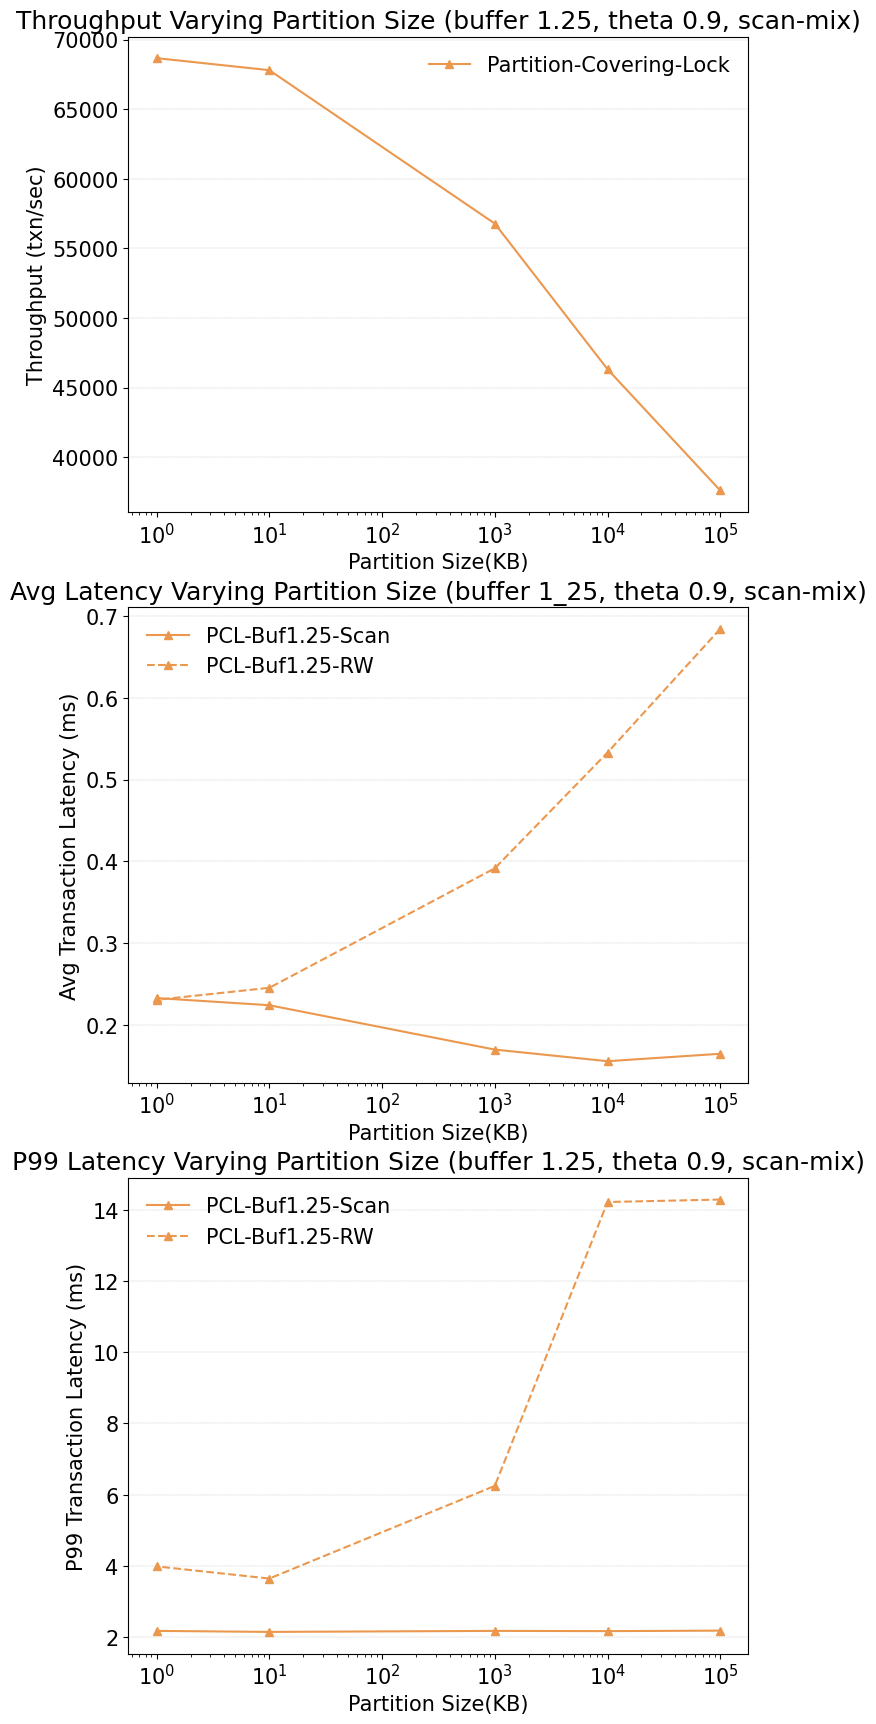

In [2]:
from process_helper import *
import numpy as np

# _, grad_colors = display_colors()
# _, bar_colors = select_color_idx(4)
color_indices, line_colors = select_color_idx(4)

plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5
idxs = ["g_total_buf_sz", "read_perc_","g_total_buf_sz"]
datadir = "../output/"
# exp_next_key = "exp_scan_mix_vary_zipf"
exp_partition_lock = "exp_mix_scan_partition_lock_vary_psize"

# data_next_key = [json.loads(line) for line in open(datadir + exp_next_key + ".txt")]
# df_next_key = pd.DataFrame().from_records(data_next_key)
# df_next_key = df_next_key.sort_values(by='zipf_theta_')

data_partition_lock = [json.loads(line) for line in open(datadir + exp_partition_lock + ".txt")]
df_partition_lock = pd.DataFrame().from_records(data_partition_lock)
# df_partition_lock = df_partition_lock.sort_values(by='zipf_theta_')

buf_df_1_25 = apply_mask(df_partition_lock, [
    ["g_total_buf_sz", ["eq", 15000000000]]
])

buf_df_0_75 = apply_mask(df_partition_lock, [
    ["g_total_buf_sz", ["eq", 9000000000]]
])


buf_df_0_25 = apply_mask(df_partition_lock, [
    ["g_total_buf_sz", ["eq", 3000000000]]
])


# print(df_tuple)
fig = plt.figure(figsize=(8, 21))

# fig, ax = plt.subplots()
ax = fig.add_subplot(3, 1, 1)

# ax.plot(df_next_key["g_partition_covering_lock_unit_sz"], 
#         df_next_key["throughput_txn_per_sec"],
#         color=line_colors["BLUE"],
#         marker="s", label="Bonsai")


ax.plot(buf_df_1_25["g_partition_covering_lock_unit_sz"], 
        buf_df_1_25["throughput_txn_per_sec"],
        color=line_colors["ORANGE"],
        marker="^", label="Partition-Covering-Lock")

# ax.set_ylim(10, 11000)
#ax.set_xlim(0, 1)
ax.set_xticks(buf_df_1_25["g_partition_covering_lock_unit_sz"])
ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Throughput (txn/sec)")
ax.set_xlabel("Partition Size(KB)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Throughput Varying Partition Size (buffer 1.25, theta 0.9, scan-mix)")



ax = fig.add_subplot(3, 1, 2)


# ax.plot(df_next_key["zipf_theta_"], 
#         df_next_key["avg_sum_scan_txn_latency (us)"]/1000,
#         color=line_colors["BLUE"],
#         marker="s", label="Bonsai-Scan")
# ax.plot(df_next_key["zipf_theta_"], 
#         # df_tuple["txn_latency_perc99_us"]/1000,
#         df_next_key["avg_sum_rw_txn_latency (us)"]/1000,
#         color=line_colors["BLUE"],
#         marker="s", label="Bonsai-RW", linestyle='dashed')


ax.plot(buf_df_1_25["g_partition_covering_lock_unit_sz"], 
    # df_tuple["txn_latency_perc99_us"]/1000,
        buf_df_1_25["avg_sum_scan_txn_latency (us)"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-Buf1.25-Scan")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page["g_total_buf_sz"])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(buf_df_1_25["g_partition_covering_lock_unit_sz"], 
    # df_page_idx_evict["txn_latency_perc99_us"]/1000,
        buf_df_1_25["avg_sum_rw_txn_latency (us)"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-Buf1.25-RW", linestyle='dashed')

# ax.set_ylim(0, 125)
#ax.set_xlim(0, 1)
ax.set_xticks(buf_df_1_25["g_partition_covering_lock_unit_sz"])
ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Avg Transaction Latency (ms)")
# ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
ax.set_xlabel("Partition Size(KB)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Avg Latency Varying Partition Size (buffer 1_25, theta 0.9, scan-mix)")


ax = fig.add_subplot(3, 1, 3)

# ax.plot(df_next_key["zipf_theta_"], 
#         df_next_key["scan_txn_latency_perc99_us"]/1000,
#         # df_tuple["avg_sum_txn_latency (us)"]/1000,
#         color=line_colors["BLUE"],
#         marker="s", label="Bonsai")

# ax.plot(df_next_key["zipf_theta_"], 
#         df_next_key["rw_txn_latency_perc99_us"]/1000,
#         # df_tuple["avg_sum_txn_latency (us)"]/1000,
#         color=line_colors["BLUE"],
#         marker="s", label="Bonsai",linestyle='dashed')



ax.plot(buf_df_1_25["g_partition_covering_lock_unit_sz"], 
        buf_df_1_25["scan_txn_latency_perc99_us"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-Buf1.25-Scan")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page["g_total_buf_sz"])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(buf_df_1_25["g_partition_covering_lock_unit_sz"], 
        buf_df_1_25["rw_txn_latency_perc99_us"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-Buf1.25-RW", linestyle='dashed')

# ax.set_ylim(0, 700)
#ax.set_xlim(0, 1)
ax.set_xticks(buf_df_1_25["g_partition_covering_lock_unit_sz"])
ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("P99 Transaction Latency (ms)")
ax.set_xlabel("Partition Size(KB)")# ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("P99 Latency Varying Partition Size (buffer 1.25, theta 0.9, scan-mix)")


Text(0.5, 1.0, 'P99 Latency Varying Buffer Size (theta 0.9, writeheavy)')

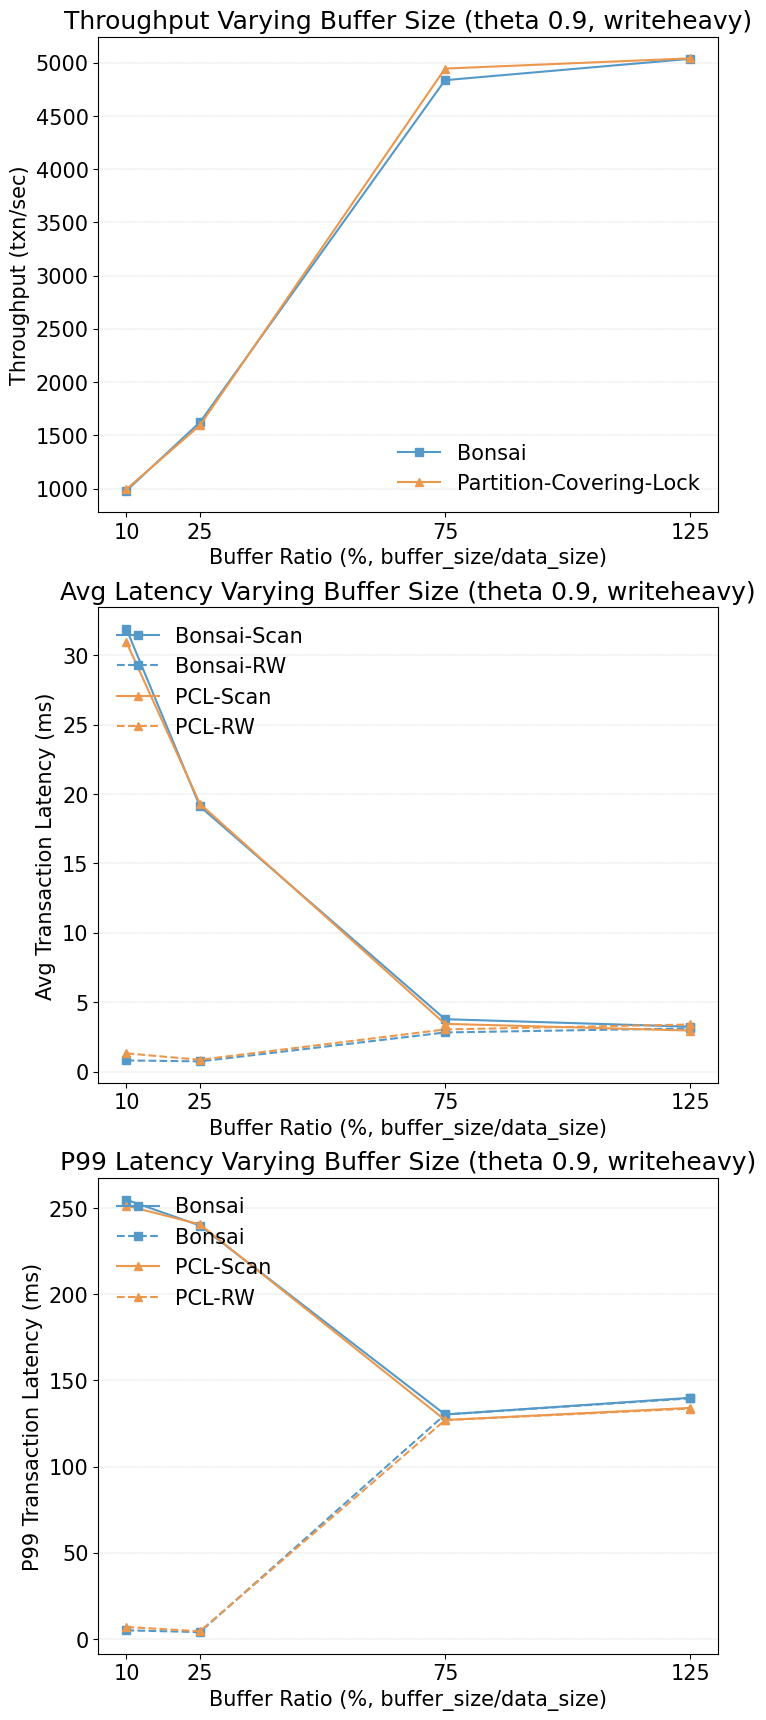

In [3]:
from process_helper import *
import numpy as np

# _, grad_colors = display_colors()
# _, bar_colors = select_color_idx(4)
color_indices, line_colors = select_color_idx(4)

plt.rcParams.update({'font.size': 15})
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 0.5
idxs = ["g_total_buf_sz", "read_perc_","g_total_buf_sz"]
datadir = "../output/"
exp_next_key = "exp_scan_mix_vary_buf"
exp_partition_lock = "exp_mix_scan_partition_lock_vary_buf"

data_next_key = [json.loads(line) for line in open(datadir + exp_next_key + ".txt")]
df_next_key = pd.DataFrame().from_records(data_next_key)
df_next_key = df_next_key.sort_values(by='g_total_buf_sz')

data_partition_lock = [json.loads(line) for line in open(datadir + exp_partition_lock + ".txt")]
df_partition_lock = pd.DataFrame().from_records(data_partition_lock)
df_partition_lock = df_partition_lock.sort_values(by='g_total_buf_sz')

# print(df_tuple)
fig = plt.figure(figsize=(8, 21))

# fig, ax = plt.subplots()
ax = fig.add_subplot(3, 1, 1)


ax.plot(df_next_key["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_next_key["throughput_txn_per_sec"],
        color=line_colors["BLUE"],
        marker="s", label="Bonsai")


ax.plot(df_partition_lock["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_partition_lock["throughput_txn_per_sec"],
        color=line_colors["ORANGE"],
        marker="^", label="Partition-Covering-Lock")

# ax.set_ylim(10, 11000)
#ax.set_xlim(0, 1)
ax.set_xticks(df_next_key["g_total_buf_sz"] * 100/(12*1000*1000*1000))
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "best"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Throughput (txn/sec)")
ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Throughput Varying Buffer Size (theta 0.9, writeheavy)")



ax = fig.add_subplot(3, 1, 2)


ax.plot(df_next_key["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_next_key["avg_sum_scan_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai-Scan")
ax.plot(df_next_key["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        # df_tuple["txn_latency_perc99_us"]/1000,
        df_next_key["avg_sum_rw_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai-RW", linestyle='dashed')


ax.plot(df_partition_lock["g_total_buf_sz"]*100/(12*1000*1000*1000), 
    # df_tuple["txn_latency_perc99_us"]/1000,
        df_partition_lock["avg_sum_scan_txn_latency (us)"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-Scan")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page["g_total_buf_sz"])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_partition_lock["g_total_buf_sz"]*100/(12*1000*1000*1000), 
    # df_page_idx_evict["txn_latency_perc99_us"]/1000,
        df_partition_lock["avg_sum_rw_txn_latency (us)"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-RW", linestyle='dashed')

# ax.set_ylim(0, 125)
#ax.set_xlim(0, 1)
ax.set_xticks(df_next_key["g_total_buf_sz"] * 100/(12*1000*1000*1000))
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "upper left"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("Avg Transaction Latency (ms)")
ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("Avg Latency Varying Buffer Size (theta 0.9, writeheavy)")

ax = fig.add_subplot(3, 1, 3)


# ax.plot(df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000), 
#         # df_tuple["txn_latency_perc99_us"]/1000,
#         df_tuple["avg_sum_txn_latency (us)"]/1000,
#         color=line_colors["BLUE"],
#         marker="s", label="Bonsai")

ax.plot(df_next_key["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_next_key["scan_txn_latency_perc99_us"]/1000,
        # df_tuple["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai")

ax.plot(df_next_key["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_next_key["rw_txn_latency_perc99_us"]/1000,
        # df_tuple["avg_sum_txn_latency (us)"]/1000,
        color=line_colors["BLUE"],
        marker="s", label="Bonsai",linestyle='dashed')



ax.plot(df_partition_lock["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_partition_lock["scan_txn_latency_perc99_us"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-Scan")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page["g_total_buf_sz"])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page["g_total_buf_sz"][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_partition_lock["g_total_buf_sz"]*100/(12*1000*1000*1000), 
        df_partition_lock["rw_txn_latency_perc99_us"]/1000,
        color=line_colors["ORANGE"],
        marker="^", label="PCL-RW", linestyle='dashed')

# ax.set_ylim(0, 700)
#ax.set_xlim(0, 1)
ax.set_xticks(df_next_key["g_total_buf_sz"] * 100/(12*1000*1000*1000))
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "upper left"
ax.legend(loc=location, frameon=False)
ax.set_ylabel("P99 Transaction Latency (ms)")
ax.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax.set_title("P99 Latency Varying Buffer Size (theta 0.9, writeheavy)")
